<a href="https://colab.research.google.com/github/ludmila-sla/aulas-mestrado/blob/main/mlp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import pandas as pd
from google.colab import drive
import matplotlib.pyplot as plt
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
class MLP(nn.Module):
    def __init__(self, layers, activation='relu', dropout=0.0):
        super().__init__()

        self.layers = nn.ModuleList()

        for i in range(len(layers) - 1):
            self.layers.append(nn.Linear(layers[i], layers[i+1]))

        if activation == 'relu':
            self.act_fn = nn.ReLU()
        elif activation == 'tanh':
            self.act_fn = nn.Tanh()

        self.dropout = nn.Dropout(dropout)
    def forward(self, x):
        for i in range(len(self.layers) - 1):
            x = self.layers[i](x)
            x = self.act_fn(x)
            x = self.dropout(x)

        x = self.layers[-1](x)
        return x

In [ ]:
def accuracy(y_pred, y_true):
    preds = torch.argmax(y_pred, dim=1)
    return (preds == y_true).sum().item() / len(y_true)

In [ ]:
def train_model(model, X_train, y_train, X_val, y_val,
                epochs=100, lr=0.01, optimizer_type='sgd',
                patience=20, l2_lambda=0.0):

    criterion = nn.CrossEntropyLoss()

    if optimizer_type == 'sgd':
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, weight_decay=l2_lambda)
    else:
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=l2_lambda)

    best_loss = float('inf')
    patience_counter = 0

    for epoch in range(epochs):
        model.train()

        optimizer.zero_grad()
        outputs = model(X_train)
        loss = criterion(outputs, y_train)
        loss.backward()
        optimizer.step()

        train_acc = accuracy(outputs, y_train)

        model.eval()
        with torch.no_grad():
            val_outputs = model(X_val)
            val_loss = criterion(val_outputs, y_val)
            val_acc = accuracy(val_outputs, y_val)

        print(f"Epoch {epoch+1} | "
              f"Train Loss: {loss.item():.4f} Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss.item():.4f} Acc: {val_acc:.4f}")

        if val_loss < best_loss:
            best_loss = val_loss
            best_weights = model.state_dict()
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print("Early stopping")
            break

    model.load_state_dict(best_weights)

In [ ]:
def test_model(model, X_test, y_test):
    model.eval()
    with torch.no_grad():
        outputs = model(X_test)
        acc = accuracy(outputs, y_test)
    return acc

In [ ]:
print("\n==== DATASET 1 ====")

df_d1_train = pd.read_csv("/content/drive/MyDrive/trabalho perception/train_dataset1.csv")
df_d1_test = pd.read_csv("/content/drive/MyDrive/trabalho perception/test_dataset1.csv")


X_d1 = df_d1_train.drop('label', axis=1).values
y_d1 = df_d1_train['label'].values


unique_labels = sorted(set(y_d1))
label_map = {label: idx for idx, label in enumerate(unique_labels)}

y_d1 = [label_map[int(y)] for y in y_d1]


X_d1 = torch.tensor(X_d1, dtype=torch.float32)
y_d1 = torch.tensor(y_d1, dtype=torch.long)

split = int(0.8 * len(X_d1))

X_train_d1 = X_d1[:split]
y_train_d1 = y_d1[:split]

X_val_d1 = X_d1[split:]
y_val_d1 = y_d1[split:]

X_test_d1 = torch.tensor(df_d1_test.drop('label', axis=1).values, dtype=torch.float32)
y_test_raw = df_d1_test['label'].values
y_test_d1 = torch.tensor([label_map[int(y)] for y in y_test_raw], dtype=torch.long)

model_d1 = MLP([X_d1.shape[1], 8, len(torch.unique(y_d1))])

train_model(model_d1, X_train_d1, y_train_d1, X_val_d1, y_val_d1)

test_acc_d1 = test_model(model_d1, X_test_d1, y_test_d1)
print(f"Dataset 1 Test Acc: {test_acc_d1:.4f}")



==== DATASET 1 ====
Epoch 1 | Train Loss: 0.7685 Acc: 0.4911 | Val Loss: 0.7537 Acc: 0.4643
Epoch 2 | Train Loss: 0.7663 Acc: 0.4911 | Val Loss: 0.7519 Acc: 0.4643
Epoch 3 | Train Loss: 0.7640 Acc: 0.4911 | Val Loss: 0.7500 Acc: 0.4643
Epoch 4 | Train Loss: 0.7618 Acc: 0.4911 | Val Loss: 0.7483 Acc: 0.4643
Epoch 5 | Train Loss: 0.7596 Acc: 0.4911 | Val Loss: 0.7465 Acc: 0.4643
Epoch 6 | Train Loss: 0.7574 Acc: 0.4911 | Val Loss: 0.7447 Acc: 0.4643
Epoch 7 | Train Loss: 0.7552 Acc: 0.4911 | Val Loss: 0.7430 Acc: 0.4643
Epoch 8 | Train Loss: 0.7531 Acc: 0.4911 | Val Loss: 0.7413 Acc: 0.4643
Epoch 9 | Train Loss: 0.7509 Acc: 0.4911 | Val Loss: 0.7396 Acc: 0.4643
Epoch 10 | Train Loss: 0.7488 Acc: 0.4911 | Val Loss: 0.7379 Acc: 0.4643
Epoch 11 | Train Loss: 0.7468 Acc: 0.4911 | Val Loss: 0.7362 Acc: 0.4643
Epoch 12 | Train Loss: 0.7447 Acc: 0.4911 | Val Loss: 0.7346 Acc: 0.4643
Epoch 13 | Train Loss: 0.7427 Acc: 0.4911 | Val Loss: 0.7329 Acc: 0.4643
Epoch 14 | Train Loss: 0.7407 Acc: 0.49

In [ ]:
print("\n==== DATASET 2 ====")

df_d2_train = pd.read_csv("/content/drive/MyDrive/trabalho perception/train_dataset2.csv")
df_d2_test = pd.read_csv("/content/drive/MyDrive/trabalho perception/test_dataset2.csv")

X_d2 = df_d2_train.drop('label', axis=1).values
y_d2 = df_d2_train['label'].values

unique_labels = sorted(set(y_d2))
label_map = {label: idx for idx, label in enumerate(unique_labels)}

y_d2 = [label_map[int(y)] for y in y_d2]

X_d2 = torch.tensor(X_d2, dtype=torch.float32)
y_d2 = torch.tensor(y_d2, dtype=torch.long)

split = int(0.8 * len(X_d2))

X_train_d2 = X_d2[:split]
y_train_d2 = y_d2[:split]

X_val_d2 = X_d2[split:]
y_val_d2 = y_d2[split:]

X_test_d2 = torch.tensor(df_d2_test.drop('label', axis=1).values, dtype=torch.float32)
y_test_raw = df_d2_test['label'].values
y_test_d2 = torch.tensor([label_map[int(y)] for y in y_test_raw], dtype=torch.long)

model_d2 = MLP([X_d2.shape[1], 16, 16, len(torch.unique(y_d2))], activation='tanh')

train_model(model_d2, X_train_d2, y_train_d2, X_val_d2, y_val_d2)

test_acc_d2 = test_model(model_d2, X_test_d2, y_test_d2)
print(f"Dataset 2 Test Acc: {test_acc_d2:.4f}")


==== DATASET 2 ====
Epoch 1 | Train Loss: 0.7008 Acc: 0.3000 | Val Loss: 0.6660 Acc: 0.5143
Epoch 2 | Train Loss: 0.7006 Acc: 0.3071 | Val Loss: 0.6661 Acc: 0.5429
Epoch 3 | Train Loss: 0.7004 Acc: 0.3071 | Val Loss: 0.6662 Acc: 0.5429
Epoch 4 | Train Loss: 0.7003 Acc: 0.3143 | Val Loss: 0.6663 Acc: 0.5429
Epoch 5 | Train Loss: 0.7001 Acc: 0.3357 | Val Loss: 0.6664 Acc: 0.5429
Epoch 6 | Train Loss: 0.7000 Acc: 0.3429 | Val Loss: 0.6665 Acc: 0.5714
Epoch 7 | Train Loss: 0.6998 Acc: 0.3429 | Val Loss: 0.6666 Acc: 0.6286
Epoch 8 | Train Loss: 0.6997 Acc: 0.3500 | Val Loss: 0.6667 Acc: 0.6571
Epoch 9 | Train Loss: 0.6995 Acc: 0.3429 | Val Loss: 0.6668 Acc: 0.6857
Epoch 10 | Train Loss: 0.6994 Acc: 0.3571 | Val Loss: 0.6669 Acc: 0.6857
Epoch 11 | Train Loss: 0.6992 Acc: 0.3571 | Val Loss: 0.6670 Acc: 0.6857
Epoch 12 | Train Loss: 0.6991 Acc: 0.3714 | Val Loss: 0.6671 Acc: 0.6857
Epoch 13 | Train Loss: 0.6989 Acc: 0.3643 | Val Loss: 0.6672 Acc: 0.6857
Epoch 14 | Train Loss: 0.6988 Acc: 0.37

O Dataset 2 apresenta um problema de classificação não-linear, no qual as classes não podem ser separadas por uma fronteira linear.
Para resolver esse problema, foi utilizada uma MLP com duas camadas ocultas e função de ativação não-linear (Tanh), permitindo a modelagem de relações complexas entre os dados.

In [ ]:
print("\n==== DATASET 4 ====")

df_train = pd.read_csv("/content/drive/MyDrive/mlp/train_dataset.csv")
df_val = pd.read_csv("/content/drive/MyDrive/mlp/validation_dataset.csv")
df_test = pd.read_csv("/content/drive/MyDrive/mlp/test_dataset.csv")


==== DATASET 4 ====


In [ ]:
X_train_loaded = df_train.drop('label', axis=1).values.T
y_train_loaded = df_train['label'].values.reshape(1, -1)

X_val_loaded = df_val.drop('label', axis=1).values.T
y_val_loaded = df_val['label'].values.reshape(1, -1)

X_test_loaded = df_test.drop('label', axis=1).values.T
y_test_loaded = df_test['label'].values.reshape(1, -1)


X_train = torch.tensor(X_train_loaded.T, dtype=torch.float32)
y_train = torch.tensor(y_train_loaded.flatten(), dtype=torch.long)

X_val = torch.tensor(X_val_loaded.T, dtype=torch.float32)
y_val = torch.tensor(y_val_loaded.flatten(), dtype=torch.long)

X_test = torch.tensor(X_test_loaded.T, dtype=torch.float32)
y_test = torch.tensor(y_test_loaded.flatten(), dtype=torch.long)

In [ ]:
architectures = {
    "small": [50, 64, 4],
    "medium": [50, 128, 64, 4],
    "large": [50, 256, 128, 64, 4]
}

optimizers = {
    "sgd": 0.01,
    "adam": 0.001
}

activations = ["relu", "tanh"]

regularizations = {
    "none": {"dropout": 0.0, "l2": 0.0},
    "dropout": {"dropout": 0.1, "l2": 0.0},
    "l2": {"dropout": 0.0, "l2": 0.001}
}

In [ ]:
results = []

for arch_name, arch in architectures.items():
    for opt_name, lr in optimizers.items():
        for act in activations:
            for reg_name, reg in regularizations.items():

                print(f"\nRodando: {arch_name} | {opt_name} | {act} | {reg_name}")

                model = MLP(arch, activation=act, dropout=reg["dropout"])

                train_model(
                    model,
                    X_train, y_train,
                    X_val, y_val,
                    epochs=100,
                    lr=lr,
                    optimizer_type=opt_name,
                    patience=20,
                    l2_lambda=reg["l2"]
                )

                test_acc = test_model(model, X_test, y_test)

                results.append({
                    "arch": arch_name,
                    "optimizer": opt_name,
                    "activation": act,
                    "regularization": reg_name,
                    "test_acc": test_acc
                })

                print(f"Test Acc: {test_acc:.4f}")


Rodando: small | sgd | relu | none
Epoch 1 | Train Loss: 1.4297 Acc: 0.2331 | Val Loss: 1.4318 Acc: 0.2552
Epoch 2 | Train Loss: 1.4278 Acc: 0.2370 | Val Loss: 1.4301 Acc: 0.2552
Epoch 3 | Train Loss: 1.4259 Acc: 0.2370 | Val Loss: 1.4284 Acc: 0.2552
Epoch 4 | Train Loss: 1.4240 Acc: 0.2370 | Val Loss: 1.4267 Acc: 0.2552
Epoch 5 | Train Loss: 1.4222 Acc: 0.2383 | Val Loss: 1.4251 Acc: 0.2500
Epoch 6 | Train Loss: 1.4203 Acc: 0.2383 | Val Loss: 1.4234 Acc: 0.2500
Epoch 7 | Train Loss: 1.4185 Acc: 0.2409 | Val Loss: 1.4218 Acc: 0.2448
Epoch 8 | Train Loss: 1.4167 Acc: 0.2448 | Val Loss: 1.4202 Acc: 0.2500
Epoch 9 | Train Loss: 1.4149 Acc: 0.2474 | Val Loss: 1.4186 Acc: 0.2552
Epoch 10 | Train Loss: 1.4131 Acc: 0.2513 | Val Loss: 1.4170 Acc: 0.2552
Epoch 11 | Train Loss: 1.4113 Acc: 0.2513 | Val Loss: 1.4154 Acc: 0.2552
Epoch 12 | Train Loss: 1.4096 Acc: 0.2526 | Val Loss: 1.4138 Acc: 0.2552
Epoch 13 | Train Loss: 1.4078 Acc: 0.2539 | Val Loss: 1.4123 Acc: 0.2552
Epoch 14 | Train Loss: 1

In [ ]:
df_results = pd.DataFrame(results)
print(df_results)

df_results.to_csv("results.csv", index=False)


      arch optimizer activation regularization  test_acc
0    small       sgd       relu           none  0.400000
1    small       sgd       relu        dropout  0.416667
2    small       sgd       relu             l2  0.400000
3    small       sgd       tanh           none  0.591667
4    small       sgd       tanh        dropout  0.666667
5    small       sgd       tanh             l2  0.583333
6    small      adam       relu           none  0.687500
7    small      adam       relu        dropout  0.679167
8    small      adam       relu             l2  0.687500
9    small      adam       tanh           none  0.737500
10   small      adam       tanh        dropout  0.708333
11   small      adam       tanh             l2  0.745833
12  medium       sgd       relu           none  0.366667
13  medium       sgd       relu        dropout  0.379167
14  medium       sgd       relu             l2  0.358333
15  medium       sgd       tanh           none  0.595833
16  medium       sgd       tanh

      arch optimizer activation regularization  test_acc
23  medium      adam       tanh             l2  0.795833
31   large      adam       relu        dropout  0.795833
22  medium      adam       tanh        dropout  0.791667
21  medium      adam       tanh           none  0.787500
34   large      adam       tanh        dropout  0.787500
35   large      adam       tanh             l2  0.787500
32   large      adam       relu             l2  0.779167
33   large      adam       tanh           none  0.779167
30   large      adam       relu           none  0.775000
19  medium      adam       relu        dropout  0.766667
20  medium      adam       relu             l2  0.766667
18  medium      adam       relu           none  0.766667
11   small      adam       tanh             l2  0.745833
9    small      adam       tanh           none  0.737500
17  medium       sgd       tanh             l2  0.720833
10   small      adam       tanh        dropout  0.708333
6    small      adam       relu

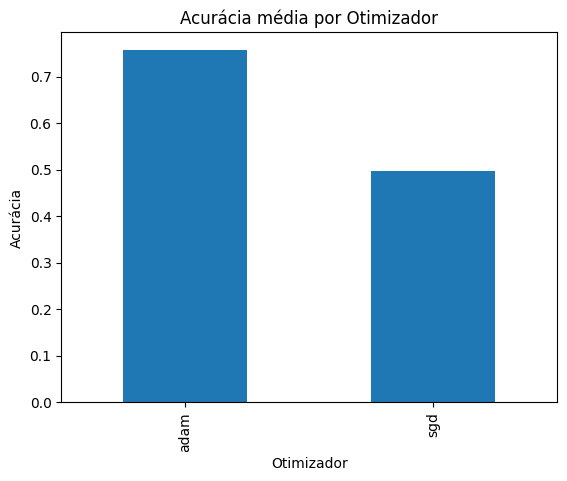

In [ ]:
print(df_results.sort_values(by="test_acc", ascending=False))
df_results.groupby("optimizer")["test_acc"].mean().plot(kind="bar")
plt.title("Acurácia média por Otimizador")
plt.ylabel("Acurácia")
plt.xlabel("Otimizador")
plt.show()

O otimizador Adam apresentou maior estabilidade durante o treinamento, com convergência mais rápida e menor oscilação na função de perda. Em comparação, o SGD apresentou maior variabilidade entre épocas, especialmente nas arquiteturas mais profundas.


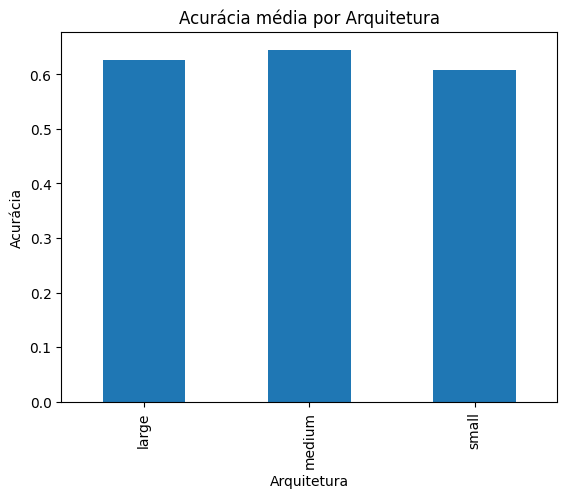

In [ ]:
df_results.groupby("arch")["test_acc"].mean().plot(kind="bar")
plt.title("Acurácia média por Arquitetura")
plt.ylabel("Acurácia")
plt.xlabel("Arquitetura")
plt.show()

A arquitetura pequena apresentou sinais de underfitting, com desempenho inferior tanto no treino quanto na validação, indicando baixa capacidade de modelar o problema.
A arquitetura grande apresentou indícios de overfitting, com alta acurácia no treino, mas pior desempenho na validação.
A arquitetura média apresentou o melhor equilíbrio entre capacidade de aprendizado e generalização.

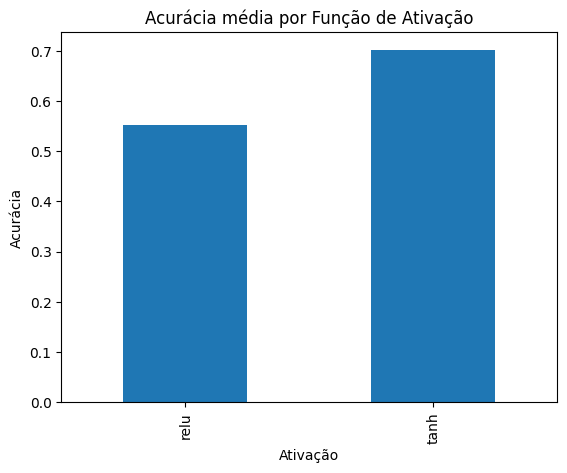

In [ ]:
df_results.groupby("activation")["test_acc"].mean().plot(kind="bar")
plt.title("Acurácia média por Função de Ativação")
plt.ylabel("Acurácia")
plt.xlabel("Ativação")
plt.show()

A função Tamh apresentou melhor desempenho geral, com treinamento mais estável e convergência mais rápida.


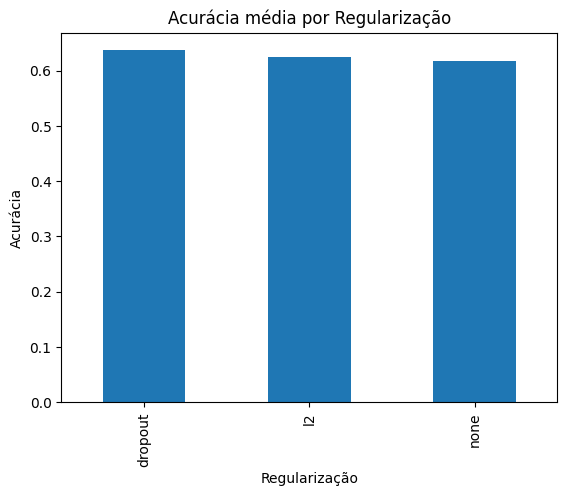

In [ ]:
df_results.groupby("regularization")["test_acc"].mean().plot(kind="bar")
plt.title("Acurácia média por Regularização")
plt.ylabel("Acurácia")
plt.xlabel("Regularização")
plt.show()

A utilização de dropout contribuiu para reduzir o overfitting, especialmente nas arquiteturas maiores.
A regularização L2 também apresentou impacto positivo, porém menos significativo que o dropout.
Modelos sem regularização apresentaram maior tendência ao overfitting.